## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models

## Load Dataset

In [2]:
dataset_path = Path("../dataset")
dl_data_path = dataset_path / "dl_data"

X_train = np.load(dl_data_path / "X_train.npy")
X_validation = np.load(dl_data_path / "X_validation.npy")
X_test = np.load(dl_data_path / "X_test.npy")

y_train = np.load(dl_data_path / "y_train.npy")
y_validation = np.load(dl_data_path / "y_validation.npy")
y_test = np.load(dl_data_path / "y_test.npy")

print("===== Datasets loaded successfully. =====")

===== Datasets loaded successfully. =====


## Preprocessing & Normalization

In [3]:
X_train = X_train.astype(np.float32)
X_validation = X_validation.astype(np.float32)
X_test = X_test.astype(np.float32)

# Calculate statistics only from training data
train_mean = X_train.mean()
train_std = X_train.std()

# Normalize
X_train = (X_train - train_mean) / train_std
X_validation = (X_validation - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("===== NORMALIZATION CHECK =====")

print("Train:")
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("\nValidation:")
print("Mean:", X_validation.mean())
print("Std:", X_validation.std())

print("\nTest:")
print("Mean:", X_test.mean())
print("Std:", X_test.std())

===== NORMALIZATION CHECK =====
Train:
Mean: 8.628554e-08
Std: 1.0000006

Validation:
Mean: 0.00015843338
Std: 1.0341631

Test:
Mean: 0.0026376029
Std: 1.0162377


## Add Channel Dimension

In [4]:
X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("\n===== XCEPTION INPUT SHAPES =====")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)


===== XCEPTION INPUT SHAPES =====
X_train: (5969, 9000, 1)
X_validation: (1279, 9000, 1)
X_test: (1280, 9000, 1)


## Xception Block

In [5]:
def xception_block(
    x,
    filters,
    kernel_size=7,
    stride=1
):
    
    residual = x

    # First depthwise separable convolution
    x = layers.SeparableConv1D(
        filters=filters,
        kernel_size=kernel_size,
        strides=stride,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    # Second depthwise separable convolution
    x = layers.SeparableConv1D(
        filters=filters,
        kernel_size=kernel_size,
        padding="same",
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)

    # Match residual dimensions
    if residual.shape[-1] != filters or stride != 1:
        residual = layers.Conv1D(
            filters=filters,
            kernel_size=1,
            strides=stride,
            padding="same",
            use_bias=False
        )(residual)

        residual = layers.BatchNormalization()(residual)

    # Residual connection
    x = layers.Add()([x, residual])

    x = layers.Activation("relu")(x)

    return x

## Build 1D Xception Model

In [6]:
inputs = layers.Input(
    shape=(9000, 1)
)

x = inputs


# Initial convolution
x = layers.Conv1D(
    filters=32,
    kernel_size=7,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)


# Xception Block 1
x = xception_block(
    x,
    filters=32,
    kernel_size=7,
    stride=1
)


# Downsampling
x = layers.MaxPooling1D(
    pool_size=3,
    strides=2,
    padding="same"
)(x)


# Xception Block 2
x = xception_block(
    x,
    filters=64,
    kernel_size=7,
    stride=1
)


# Downsampling
x = layers.MaxPooling1D(
    pool_size=3,
    strides=2,
    padding="same"
)(x)


# Xception Block 3
x = xception_block(
    x,
    filters=128,
    kernel_size=5,
    stride=1
)


# Downsampling
x = layers.MaxPooling1D(
    pool_size=3,
    strides=2,
    padding="same"
)(x)


# Xception Block 4
x = xception_block(
    x,
    filters=256,
    kernel_size=5,
    stride=1
)


# Global Average Pooling
x = layers.GlobalAveragePooling1D()(x)


# Fully connected layer
x = layers.Dense(
    64,
    activation="relu"
)(x)


# Output layer
outputs = layers.Dense(
    4,
    activation="softmax"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="1D_Xception"
)

model.summary()

Model: "1D_Xception"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 9000, 1)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 9000, 32)     224         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 9000, 32)    128         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 9000, 32)     0           ['batch_normalization[0

## Compile Model

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Callbacks

In [8]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_1d_xception_unweighted.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully.")

Callbacks created successfully.


## Train Model

In [11]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=50,
    batch_size=8,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/50
747/747 [==============================] - ETA: 0s - loss: 0.8507 - accuracy: 0.6234
Epoch 1: val_loss improved from 1.06732 to 0.84809, saving model to best_1d_xception_unweighted.keras
747/747 [==============================] - 56s 76ms/step - loss: 0.8507 - accuracy: 0.6234 - val_loss: 0.8481 - val_accuracy: 0.6271
Epoch 2/50
746/747 [============================>.] - ETA: 0s - loss: 0.7653 - accuracy: 0.6587
Epoch 2: val_loss did not improve from 0.84809
747/747 [==============================] - 56s 75ms/step - loss: 0.7653 - accuracy: 0.6586 - val_loss: 1.0826 - val_accuracy: 0.5121
Epoch 3/50
746/747 [============================>.] - ETA: 0s - loss: 0.7341 - accuracy: 0.6759
Epoch 3: val_loss did not improve from 0.84809
747/747 [==============================] - 56s 75ms/step - loss: 0.7342 - accuracy: 0.6758 - val_loss: 1.0024 - val_accuracy: 0.4801
Epoch 4/50
746/747 [============================>.] - ETA: 0s - loss: 0.7059 - accuracy: 0.6902
Epoch 4: val_loss imp

## Test Evaluation

In [12]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("===== 1D XCEPTION TEST RESULTS =====")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 [==============================] - 3s 76ms/step - loss: 0.6458 - accuracy: 0.7383
===== 1D XCEPTION TEST RESULTS =====
Test Loss: 0.6458
Test Accuracy: 0.7383


## Predictions & Confusion Matrix

In [13]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

y_pred_prob = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("===== XCEPTION CONFUSION MATRIX =====")
print(cm)

40/40 [==============================] - 4s 73ms/step
===== XCEPTION CONFUSION MATRIX =====
[[649   8  98   7]
 [  6  74  32   1]
 [122  38 200   3]
 [ 13   1   6  22]]


## Classification Report

In [14]:
print("===== XCEPTION CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        digits=4
    )
)

===== XCEPTION CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           0     0.8215    0.8517    0.8363       762
           1     0.6116    0.6549    0.6325       113
           2     0.5952    0.5510    0.5722       363
           3     0.6667    0.5238    0.5867        42

    accuracy                         0.7383      1280
   macro avg     0.6737    0.6453    0.6569      1280
weighted avg     0.7337    0.7383    0.7353      1280



## Confusion Matrix Visualization

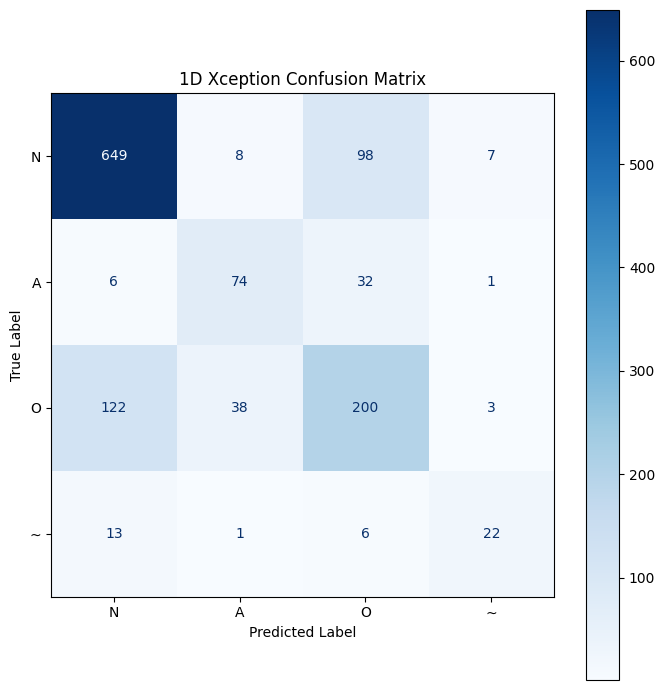

In [15]:
class_names = [
    "N",
    "A",
    "O",
    "~"
]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(
    figsize=(7, 7)
)

disp.plot(
    ax=ax,
    cmap="Blues",
    values_format="d"
)

plt.title("1D Xception Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

## Accuracy Curves

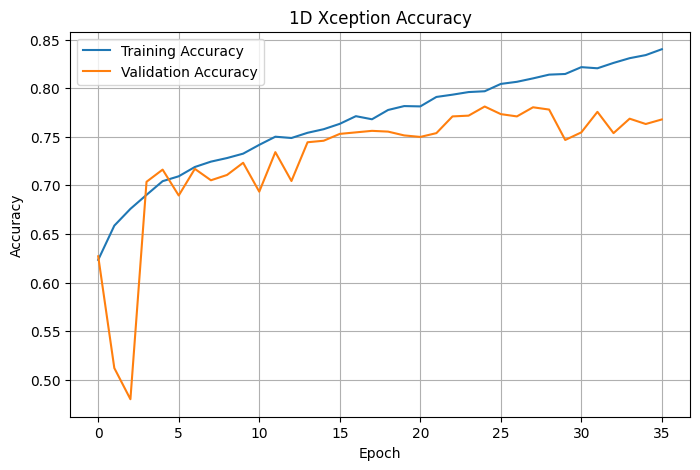

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("1D Xception Accuracy")

plt.legend()
plt.grid(True)
plt.show()

## Loss Curve

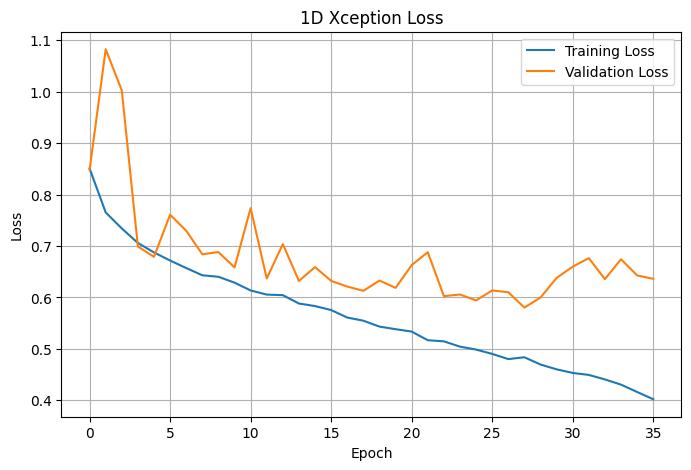

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("1D Xception Loss")

plt.legend()
plt.grid(True)
plt.show()